In [4]:
import torch
from torch import nn

In [24]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,dtype=torch.float))

    def forward(self, x: torch.tensor) -> torch.tensor:
        return self.weight * x + self.bias


In [205]:
torch.manual_seed(42)
model = LinearRegressionModel()
print(model.state_dict())

OrderedDict({'weight': tensor([0.3367]), 'bias': tensor([0.1288])})


In [28]:
import pandas as pd

data = pd.read_csv("/Users/nurma/vscode_projects/data_projects/house_rent_predictor/data/House_Rent_Dataset.csv")
data

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


In [38]:
def remove_outliers(df, columns=None, method='iqr', k=1.5, z_thresh=3.0, how='all', return_mask=False):
    """
    Remove outliers from a DataFrame using IQR or z-score method.

    Parameters
    - df: pandas.DataFrame
    - columns: list or str or None
        Columns to check for outliers. If None, numeric columns are used.
    - method: 'iqr' or 'zscore' (default 'iqr')
    - k: float
        Multiplier for IQR method (default 1.5)
    - z_thresh: float
        z-score threshold for zscore method (default 3.0)
    - how: 'all' or 'any'
        'all' -> keep rows that are non-outliers across all selected columns (AND)
        'any' -> keep rows that are non-outliers in at least one selected column (OR)
    - return_mask: bool
        If True, return (filtered_df, mask) where mask is a boolean Series of kept rows.

    Returns
    - filtered_df (or (filtered_df, mask) if return_mask=True)
    """
    # determine columns to operate on
    if columns is None:
        cols = df.select_dtypes(include=['number']).columns.tolist()
    elif isinstance(columns, str):
        cols = [columns]
    else:
        cols = list(columns)

    if not cols:
        # nothing to do
        mask = df.index.to_series().apply(lambda _: True)
        result = df.copy()
        return (result, mask) if return_mask else result

    masks = []
    for col in cols:
        series = df[col].dropna()
        if method == 'iqr':
            q1 = series.quantile(0.25)
            q3 = series.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - k * iqr
            upper = q3 + k * iqr
            col_mask = df[col].between(lower, upper) | df[col].isna()
        elif method == 'zscore':
            mean = series.mean()
            std = series.std()
            if std == 0 or std != std:  # catch zero or NaN
                col_mask = df[col].notna()
            else:
                z = (df[col] - mean).abs() / std
                col_mask = (z <= z_thresh) | df[col].isna()
        else:
            raise ValueError("method must be 'iqr' or 'zscore'")
        masks.append(col_mask)

    if how == 'all':
        combined_mask = masks[0]
        for m in masks[1:]:
            combined_mask &= m
    elif how == 'any':
        combined_mask = masks[0]
        for m in masks[1:]:
            combined_mask |= m
    else:
        raise ValueError("how must be 'all' or 'any'")

    filtered_df = df.loc[combined_mask].copy()
    return (filtered_df, combined_mask) if return_mask else filtered_df

# Example usage:
# filtered = remove_outliers(data_1var, columns=['Size','Rent'], method='iqr', k=1.5)
# filtered, mask = remove_outliers(data_1var, method='zscore', z_thresh=3.0, return_mask=True)

In [39]:
data_1var = data.loc[:,["Size","Rent"]]
data_1var

,Size,Rent
0,1100,10000
1,800,20000
2,1000,17000
3,800,10000
4,850,7500
...,...,...
4741,1000,15000
4742,2000,29000
4743,1750,35000
4744,1500,45000


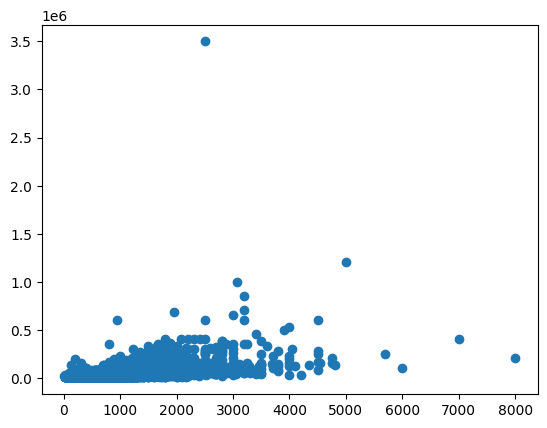

In [40]:
import matplotlib.pyplot as plt

plt.scatter(data_1var.Size, data_1var.Rent)
plt.show()

In [49]:
data1var_clean = remove_outliers(data_1var, k=3)
data1var_clean.values

array([[ 1100, 10000],
       [  800, 20000],
       [ 1000, 17000],
       ...,
       [ 1750, 35000],
       [ 1500, 45000],
       [ 1000, 15000]], shape=(4447, 2))

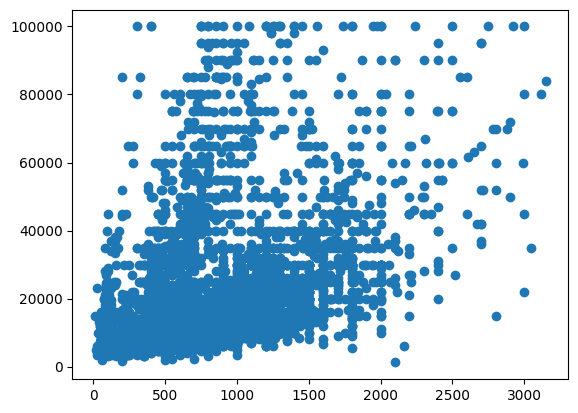

In [45]:
plt.scatter(data1var_clean.Size, data1var_clean.Rent)
plt.show()

In [83]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(torch.tensor(data1var_clean.values[:,0]),torch.tensor(data1var_clean.values[:,1]), test_size=0.2, random_state=42)

X_train,y_train

(tensor([ 850,  670,  300,  ...,  580, 3000,  600]),
 tensor([10000, 23000, 18500,  ...,  8500, 45000, 16000]))

In [84]:
with torch.inference_mode():
    y_preds = model(X_train)

y_preds

tensor([ 286.3156,  225.7114,  101.1359,  ...,  195.4092, 1010.1999,
         202.1430])

In [85]:
model.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

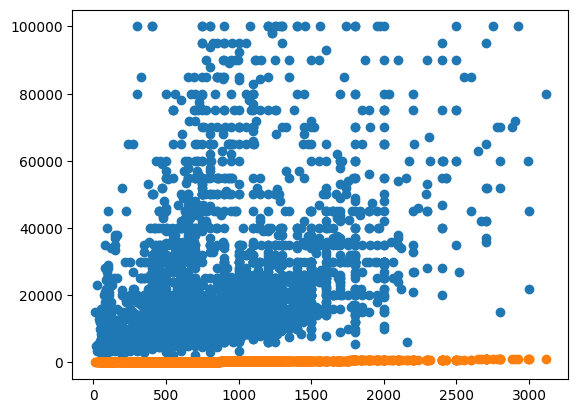

In [86]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, y_preds)
plt.show()

In [206]:
loss_mae = nn.L1Loss()
loss_mae

L1Loss()

In [207]:
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [208]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)

In [323]:
epochs = 10000

epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)
    loss = loss_mae(y_pred, y_train)
    
    optimizer.zero_grad()

    # Computes the gradients of every parameter with "require_grad=True"
    loss.backward()

    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        
        test_loss = loss_mae(test_pred, y_test)
    
    if epoch % 100 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.numpy())

        print(f"test loss: {test_loss}")



test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.3349609375
test loss: 12541.334

In [210]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

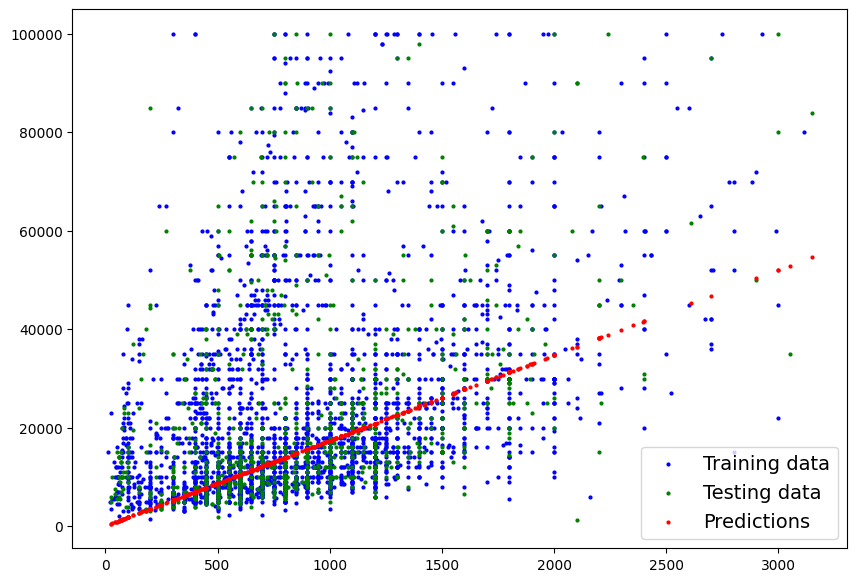

In [211]:
plot_predictions(predictions=test_pred)

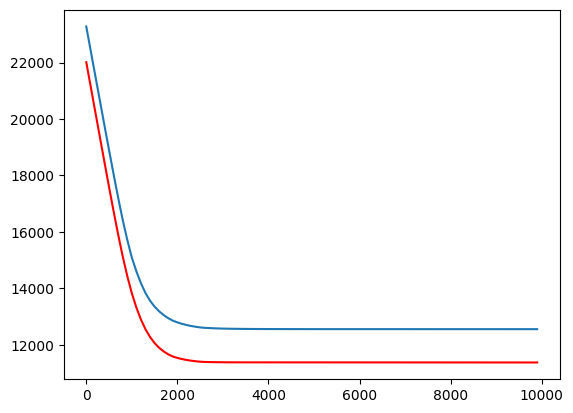

In [213]:
plt.plot(epoch_count, loss_values, c="red")
plt.plot(epoch_count, test_loss_values)

In [215]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_LR_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model.state_dict(),
           f=MODEL_SAVE_PATH)

In [223]:
model_2 = LinearRegressionModel()
model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
model_2

LinearRegressionModel()

In [224]:
model_2.state_dict()

OrderedDict([('weight', tensor([17.2436])), ('bias', tensor([169.4193]))])

In [336]:
X_train, X_test, y_train, y_test = train_test_split(torch.tensor(data1var_clean.values[:,0]),torch.tensor(data1var_clean.values[:,1]), test_size=0.2, random_state=42)

X_train,y_train

(tensor([ 850,  670,  300,  ...,  580, 3000,  600]),
 tensor([10000, 23000, 18500,  ...,  8500, 45000, 16000]))

In [372]:
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)
    def forward(self, x: torch.tensor) -> torch.tensor:
        return self.linear_layer(x)
    
torch.manual_seed(42)
model_v2 = LinearRegressionModelV2()
model_v2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [373]:
loss_model_mse = nn.L1Loss()
optimizer = torch.optim.Adam(model_v2.parameters(),lr=0.01)

loss_model_mse, optimizer

(L1Loss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     weight_decay: 0
 ))

In [374]:
X_train = X_train.type(torch.float)
X_test = X_test.type(torch.float)
y_train = y_train.type(torch.float)
y_test = y_test.type(torch.float)
X_train

tensor([[ 850.],
        [ 670.],
        [ 300.],
        ...,
        [ 580.],
        [3000.],
        [ 600.]])

In [375]:
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)
y_test = y_test.reshape(-1,1)
y_train = y_train.reshape(-1,1)
X_train

tensor([[ 850.],
        [ 670.],
        [ 300.],
        ...,
        [ 580.],
        [3000.],
        [ 600.]])

In [376]:
epochs = 100000

epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
    model_v2.train()

    train_pred = model_v2(X_train)

    loss = loss_model_mse(train_pred, y_train)

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    model_v2.eval()
    with torch.inference_mode():

        test_pred = model_v2(X_test)

        test_loss = loss_model_mse(test_pred, y_test)

    if epoch % 100 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())

test_loss_values

[22901.4921875,
 22022.2890625,
 21143.0859375,
 20265.720703125,
 19392.568359375,
 18528.89453125,
 17681.689453125,
 16865.88671875,
 16113.98046875,
 15436.9326171875,
 14869.7236328125,
 14409.248046875,
 14020.576171875,
 13698.7548828125,
 13460.8251953125,
 13272.0126953125,
 13119.8701171875,
 12997.400390625,
 12895.6337890625,
 12823.361328125,
 12765.2783203125,
 12719.8232421875,
 12681.56640625,
 12650.6181640625,
 12625.2900390625,
 12602.822265625,
 12594.330078125,
 12586.330078125,
 12579.0380859375,
 12573.703125,
 12569.359375,
 12566.591796875,
 12564.1640625,
 12562.0048828125,
 12560.2978515625,
 12558.7939453125,
 12557.6787109375,
 12556.74609375,
 12556.087890625,
 12555.478515625,
 12555.0849609375,
 12554.69140625,
 12554.2841796875,
 12553.95703125,
 12553.748046875,
 12553.53125,
 12553.30078125,
 12553.0615234375,
 12552.8115234375,
 12552.609375,
 12552.453125,
 12552.435546875,
 12552.419921875,
 12552.4013671875,
 12552.3837890625,
 12552.36328125,
 12

In [361]:
model_v2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[15.5790]])),
             ('linear_layer.bias', tensor([8484.2812]))])

In [377]:
epoch

99999

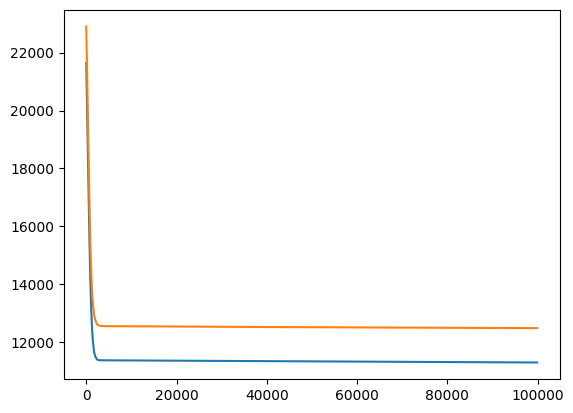

In [378]:
plt.plot(epoch_count, loss_values)
plt.plot(epoch_count, test_loss_values)